# Optical hybrid + machine learning -- a learned coherent demodulator
### recover QPSK symbols from a hybrid's (I, Q) output through noise and imbalance

A 90-degree hybrid hands the receiver an in-phase/quadrature measurement $(I,Q)$ of
each symbol. In a perfect device the four QPSK symbols sit at clean corners and a
nearest-point rule decodes them. But a real hybrid has a **fixed I/Q imbalance** --
unequal arm gains and a quadrature skew -- which is a deterministic *linear*
distortion of the constellation (plus noise). A nearest-corner rule assumes the
ideal corners, so it mis-decodes the skewed points. The imbalance is **fixed**, so a
small PyTorch **classifier** can *learn* it once and calibrate it out -- which is
exactly the kind of impairment a learned demod should beat a fixed rule on. (Random
per-symbol jitter, by contrast, is just noise and is *not* learnable -- so we model
the realistic deterministic imbalance.)

This is the classification cousin of the SEALS regression notebook, and it leans on
the same math: the $(I,Q)$ sample is a **vector**, the classifier learns **decision
regions** (linear algebra + nonlinearity), and training is **gradient descent**.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn
torch.manual_seed(0); np.random.seed(0)
print("torch", torch.__version__)

torch 2.11.0+cu128


## 1. QPSK through a hybrid with impairments

The four QPSK symbols are unit phasors at 45, 135, 225, 315 deg. A real hybrid
applies a **fixed** linear I/Q distortion $M$ (unequal gains + quadrature skew) and a
small DC offset, then adds Gaussian **noise**. The same $M$ for every symbol -- a
deterministic device imperfection the net can calibrate out.

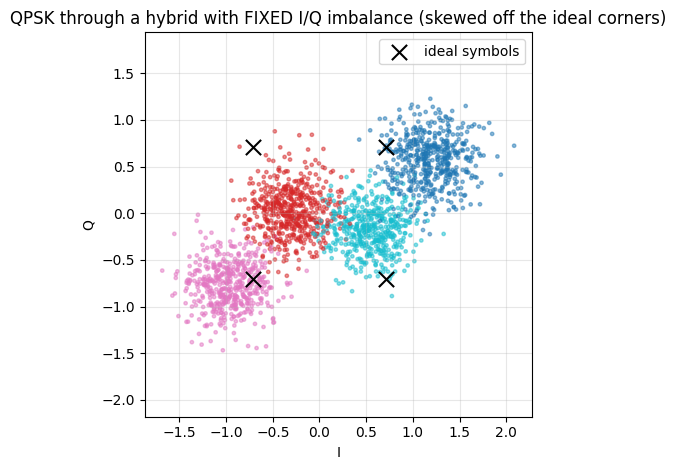

In [2]:
SYM = np.exp(1j*(np.pi/4 + np.arange(4)*np.pi/2))     # 4 QPSK constellation points
M = np.array([[1.05, 0.45],                            # fixed I/Q imbalance: gains + skew
              [0.40, 0.55]])                            # (non-orthogonal -> compresses/rotates)
OFF = np.array([0.12, -0.10])                           # DC offset
def make_data(n, snr_db=12):
    labels = np.random.randint(0, 4, n)
    ideal = np.column_stack([SYM[labels].real, SYM[labels].imag])
    meas = ideal @ M.T + OFF                            # FIXED deterministic distortion
    sigma = 10**(-snr_db/20)
    meas = meas + sigma*np.random.randn(n, 2)
    return meas.astype(np.float32), labels.astype(np.int64)

Xtr, ytr = make_data(6000); Xte, yte = make_data(2000)
plt.figure(figsize=(4.8,4.8))
plt.scatter(Xte[:,0], Xte[:,1], c=yte, s=6, cmap="tab10", alpha=0.5)
plt.scatter(SYM.real, SYM.imag, c="k", marker="x", s=120, label="ideal symbols")
plt.xlabel("I"); plt.ylabel("Q"); plt.legend(); plt.axis("equal")
plt.title("QPSK through a hybrid with FIXED I/Q imbalance (skewed off the ideal corners)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2. Baseline -- nearest ideal symbol

The classical decision: assign each $(I,Q)$ to the closest ideal constellation
point. It is optimal for noise alone, but the **phase imbalance** rotates points
across decision boundaries, so it loses accuracy.

In [3]:
def nearest_decode(X):
    pts = np.column_stack([SYM.real, SYM.imag])
    d = ((X[:,None,:] - pts[None,:,:])**2).sum(-1)
    return d.argmin(1)
base_acc = (nearest_decode(Xte) == yte).mean()
print(f"baseline (nearest-symbol) accuracy = {base_acc:.3f}")

baseline (nearest-symbol) accuracy = 0.806


## 3. A learned demodulator (PyTorch classifier)

A tiny MLP maps $(I,Q)\to$ 4 class logits, trained with cross-entropy by gradient
descent. It can bend its decision boundaries to absorb the imbalance the fixed rule
cannot.

In [4]:
net = nn.Sequential(nn.Linear(2,32), nn.ReLU(), nn.Linear(32,32), nn.ReLU(), nn.Linear(32,4))
opt = torch.optim.Adam(net.parameters(), lr=5e-3); lossf = nn.CrossEntropyLoss()
Xt = torch.tensor(Xtr); yt = torch.tensor(ytr)
for epoch in range(300):
    opt.zero_grad(); loss = lossf(net(Xt), yt); loss.backward(); opt.step()
net.eval()
with torch.no_grad():
    pred = net(torch.tensor(Xte)).argmax(1).numpy()
ml_acc = (pred == yte).mean()
print(f"learned demod accuracy = {ml_acc:.3f}   (baseline {base_acc:.3f})")

learned demod accuracy = 0.957   (baseline 0.806)


## 4. Decision regions + accuracy vs SNR

Left: the learned classifier's decision regions (it has rotated/curved the
boundaries to fit the impaired constellation). Right: accuracy vs SNR -- the learned
demod stays ahead of the nearest-symbol rule because it compensates the imbalance.

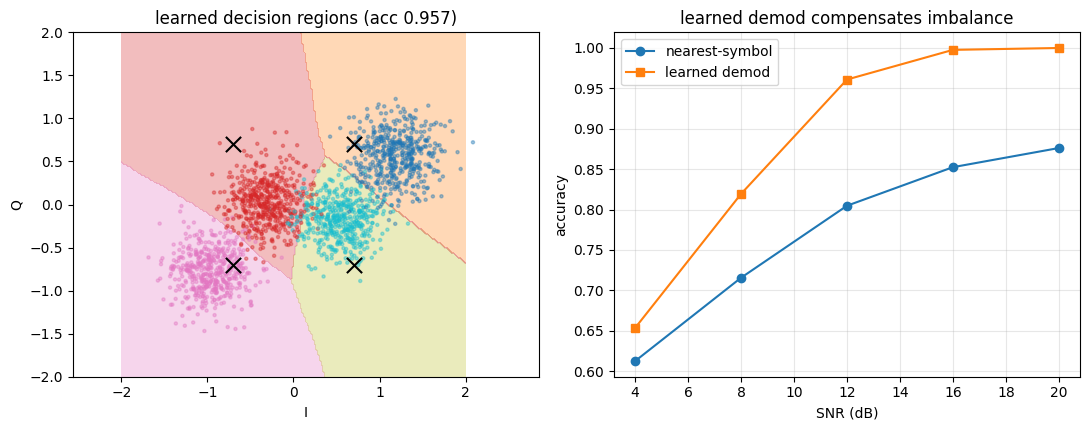

In [5]:
# decision regions
gx, gy = np.meshgrid(np.linspace(-2,2,200), np.linspace(-2,2,200))
grid = np.column_stack([gx.ravel(), gy.ravel()]).astype(np.float32)
with torch.no_grad(): zz = net(torch.tensor(grid)).argmax(1).numpy().reshape(gx.shape)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
ax[0].contourf(gx, gy, zz, alpha=0.3, cmap="tab10", levels=3)
ax[0].scatter(Xte[:,0], Xte[:,1], c=yte, s=5, cmap="tab10", alpha=0.4)
ax[0].scatter(SYM.real, SYM.imag, c="k", marker="x", s=120)
ax[0].set(xlabel="I", ylabel="Q", title=f"learned decision regions (acc {ml_acc:.3f})"); ax[0].axis("equal")

snrs = [4, 8, 12, 16, 20]; b_acc=[]; m_acc=[]
for snr in snrs:
    Xs, ys = make_data(3000, snr_db=snr)
    b_acc.append((nearest_decode(Xs)==ys).mean())
    with torch.no_grad(): p = net(torch.tensor(Xs)).argmax(1).numpy()
    m_acc.append((p==ys).mean())
ax[1].plot(snrs, b_acc, "o-", label="nearest-symbol")
ax[1].plot(snrs, m_acc, "s-", label="learned demod")
ax[1].set(xlabel="SNR (dB)", ylabel="accuracy", title="learned demod compensates imbalance")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Takeaway

1. A hybrid gives $(I,Q)$; with noise + **phase imbalance** the constellation rotates
   and smears, and a fixed nearest-symbol rule loses accuracy.
2. A small **learned classifier** bends its decision regions to absorb the
   impairment and decodes more reliably -- a data-driven coherent demodulator.
3. Same ML machinery as the SEALS inverse net: a measurement **vector** in, a
   learned map out, trained by **gradient descent**.

The receiver theme throughout: extract the transmitted information from an impaired
physical measurement. Civilian education.